### Import modules and optimization functions

In [72]:
from optimizer import optimizer
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Define battery profile

In [73]:
energy_cap = 20
power_cap = 10
n_cycles = 2
cha_efficiency = 1
dis_efficiency = 1

optimizer_flex = optimizer(energy_cap=energy_cap, power_cap=power_cap, n_cycles=n_cycles, cha_efficiency=cha_efficiency, dis_efficiency=dis_efficiency)

In [ ]:
hist_df = pd.read_pickle(r"input/historical_data.pkl")
da_column = 'da_price'
idc_column = 'id1_price'


revenues = {}

for day, daily_prices in hist_df.groupby(hist_df.index.date):
    if len(daily_prices) != 96:
        print(f"Skipping day {day} because of insufficient data (only {len(daily_prices)} quarters).")
        continue

    daa_price_vector = daily_prices[da_column].tolist()
    idc_price_vector = daily_prices[idc_column].tolist()
    daa_revenue, idc_revenue = optimizer_flex.optimize(daa_price_vector=daa_price_vector, idc_price_vector=idc_price_vector)
    revenues[day] = [daa_revenue, idc_revenue]

revenues = pd.DataFrame().from_dict(revenues, orient='index', columns=["DA_revenue", "IDC_revenue"])
revenues.index = pd.to_datetime(revenues.index)
revenues = (revenues * 365 / (1000 * power_cap))


Skipping day 2025-01-01 because of insufficient data (only 92 quarters).
Skipping day 2025-03-30 because of insufficient data (only 92 quarters).
Skipping day 2025-10-01 because of insufficient data (only 101 quarters).
Skipping day 2025-10-26 because of insufficient data (only 108 quarters).
Skipping day 2026-03-14 because of insufficient data (only 4 quarters).


#### Sanity check: comparing revenues with benchmark


Text(0.5, 1.0, 'Annualized revenues per kW of power capacity')

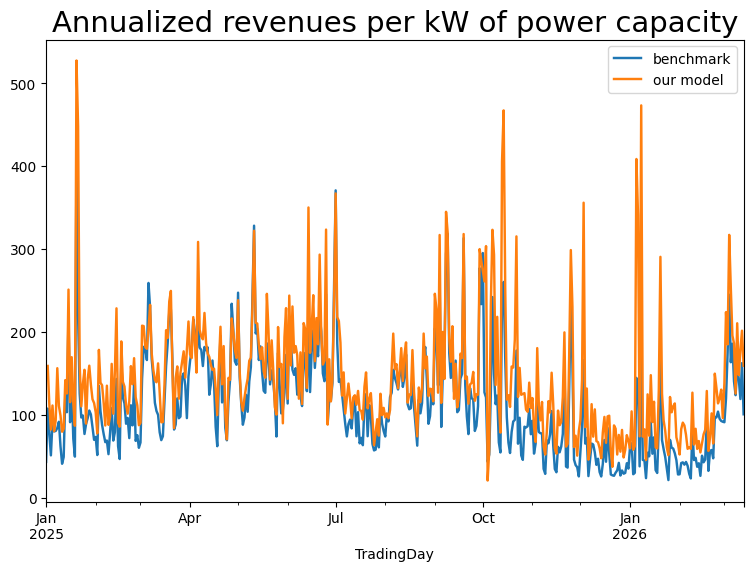

In [69]:
bess_benchmark = pd.read_excel(r"raw_input/2hr_Wholesale_BESS_Index.xlsx", index_col=0)
bess_benchmark.columns = ['benchmark']

fig, ax = plt.subplots(figsize=(9, 6))
bess_benchmark.plot(ax=ax, legend=True, linewidth=1.75)
revenues.sum(axis=1).rename('our model').plot(ax=ax, legend=True, linewidth=1.75)
ax.set_title('Annualized revenues per kW of power capacity', fontsize=21)

### plot example day optimal schedule

In [ ]:
print(3)

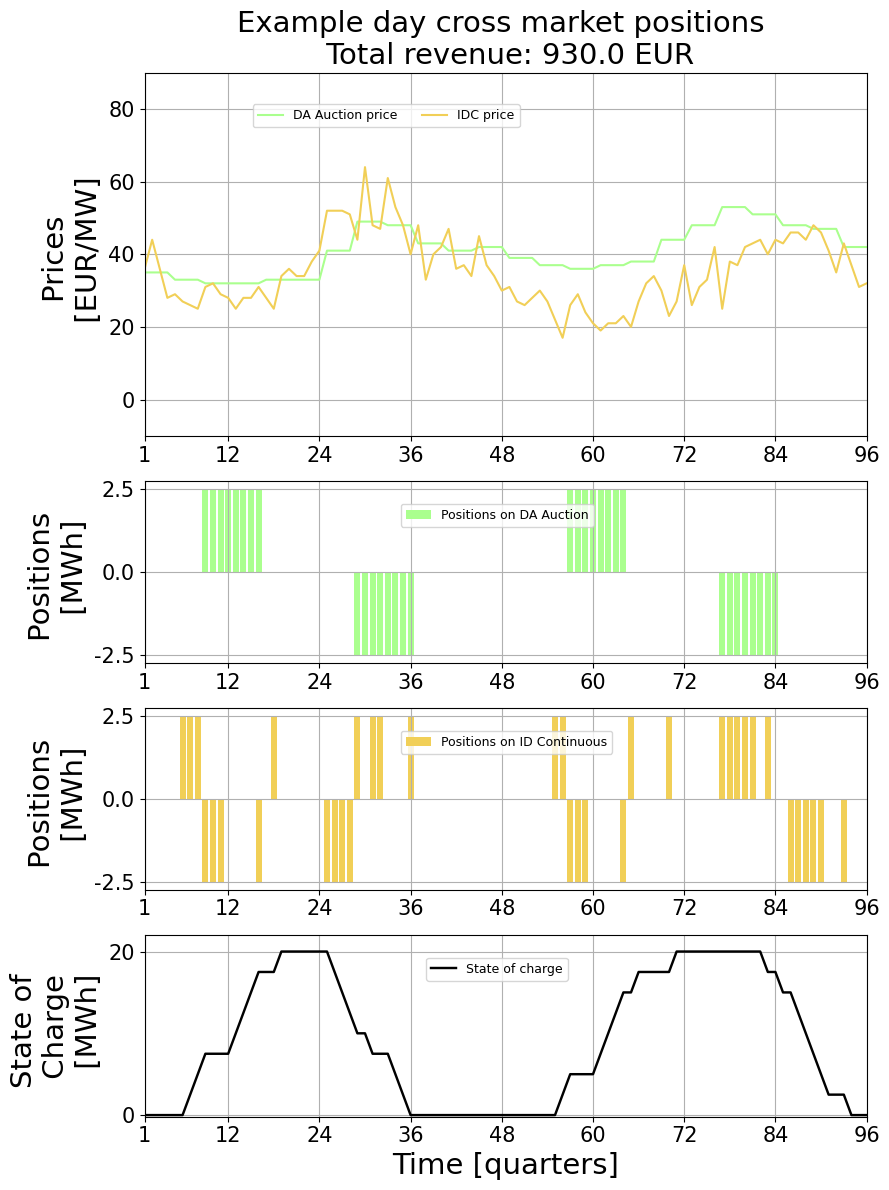

In [ ]:
color1 = (170/255,1,142/255,1)
color2 = (28/255,200/255,206/255,1)
color3 = (241/255,207/255,87/255,1)


random_day = 
xgrid = np.arange(1, 97, 1)

fig, axs = plt.subplots(4, 1, figsize=(9, 12), gridspec_kw={'height_ratios': [2,1,1,1]})

ax1, ax2, ax3, ax4= axs


# Subplot 1
ax1.plot(xgrid, daa_price_vector, color=color1, label='DA Auction price')
ax1.plot(xgrid, idc_price_vector, color=color3, label='IDC price')

ax1.legend(fontsize=9,ncol=4, loc=(0.15,0.85))
ax1.grid()
ax1.set_xlim(1, len(idc_price_vector))
ax1.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax1.set_xticklabels([1, 12, 24, 36, 48, 60, 72, 84, 96], fontsize=15)
ax1.set_yticks([0,20,40,60,80])
ax1.set_yticklabels([0,20,40,60,80], fontsize=15)
ax1.set_ylim(-10, 90)
ax1.set_ylabel('Prices \n [EUR/MW]', fontsize=21)
ax1.set_title(f'Example day cross market positions \n Total revenue: {revenue_total} EUR', fontsize=21)


# Subplot 2

ax2.bar(xgrid, np.asarray(step1_cha_daa)*power_cap/4, color=color1, label='Positions on DA Auction', linewidth=1.75)
ax2.bar(xgrid, np.asarray(step1_dis_daa)*-power_cap/4, color=color1, linewidth=1.75)

ax2.legend(fontsize=9,ncol=4, loc=(0.355,0.75))
ax2.grid()
ax2.set_xlim(1, len(idc_price_vector))
ax2.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax2.set_xticklabels([1, 12, 24, 36, 48, 60, 72, 84, 96], fontsize=15)
ax2.set_ylim(-power_cap/4*1.1, power_cap/4*1.1)
ax2.set_yticks([-power_cap/4,0, power_cap/4])
ax2.set_yticklabels(ax2.get_yticks(), fontsize=15)
ax2.set_ylabel('Positions \n [MWh]', fontsize=21)


# Subplot 3


ax3.bar(xgrid, np.asarray(step2_cha_idc)*power_cap/4, color=color3, label='Positions on ID Continuous', linewidth=1.75)
ax3.bar(xgrid, np.asarray(step2_dis_idc)*-power_cap/4, color=color3, linewidth=1.75)
ax3.bar(xgrid, np.asarray(step2_cha_idc_close)*power_cap/4, color=color3, linewidth=1.75)
ax3.bar(xgrid, np.asarray(step2_dis_idc_close)*-power_cap/4, color=color3, linewidth=1.75)

ax3.legend(fontsize=9,ncol=4, loc=(0.355,0.75))
ax3.grid()
ax3.set_xlim(1, len(idc_price_vector))
ax3.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax3.set_xticklabels([1, 12, 24, 36, 48, 60, 72, 84, 96], fontsize=15)
ax3.set_ylim(-power_cap/4*1.1, power_cap/4*1.1)
ax3.set_yticks([-power_cap/4,0, power_cap/4])
ax3.set_yticklabels(ax2.get_yticks(), fontsize=15)
ax3.set_ylabel('Positions \n [MWh]', fontsize=21)


# Subplot 5

ax4.plot(xgrid, step2_soc_idc, color='black', label='State of charge', linewidth=1.75)

ax4.legend(fontsize=9,ncol=4, loc=(0.39,0.75))
ax4.grid()
ax4.set_xlim(1, len(idc_price_vector))
ax4.set_xticks([1, 12, 24, 36, 48, 60, 72, 84, 96])
ax4.set_xticklabels([1, 12, 24, 36, 48, 60, 72, 84, 96], fontsize=15)
ax4.set_xlabel('Time [quarters]', fontsize=21)
ax4.set_ylim(-0.2, energy_cap*1.1)
ax4.set_yticks([0, energy_cap])
ax4.set_yticklabels(ax4.get_yticks(), fontsize=15)
ax4.set_ylabel('State of \n Charge \n [MWh]', fontsize=21)

plt.tight_layout()
plt.show()
